# Cibersegurança no Brasil (2015–2024)
**Avaliação G1 — Análise e Visualização de Dados com Python**

Aluna: Larissa Villela dos Santos 
Professor: Alexandre Neves Louzada
Matéria: Linguagem de Programação


## 1. Introdução ao problema
Incidentes cibernéticos (malware, ransomware, phishing etc.) causam perdas financeiras e paralisam sistemas em setores essenciais. Muito importante a análise de incidentes para entender padrões e tendências e criar uma proteção contra esses incidentes.

**Perguntas:** 
1. como os incidentes e o impacto evoluíram no tempo? 
2. quais regiões, UFs e setores concentram as perdas? 
3. quais ataques e vulnerabilidades pesam mais? 
4. existe relação estatística entre as variáveis numéricas?

## 2. Explicação da base de dados
Base **simulacao_ciberseguranca_brasil.csv** com registros mensais de 2015 a 2024 por UF, setor e tipo de ataque.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período do registro |
| regiao, uf | Localização |
| setor | Saúde, Financeiro, Governo, Educação, Varejo |
| tipo_ataque | Ransomware, Malware, Vazamento, Phishing, DDoS |
| vulnerabilidade | Falha humana, Senha fraca, Sem MFA, Sistema desatualizado |
| incidentes | Nº de incidentes no registro |
| impacto_financeiro | Prejuízo em R$ |
| tempo_recuperacao | Horas até recuperação |
| sistemas_afetados | Nº de sistemas afetados |
| nivel_criticidade | Baixo, Médio, Alto, Crítico |
| status_resposta | Resolvido, Mitigado, Em análise |

## 3. Leitura dos dados

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../dados/simulacao_ciberseguranca_brasil.csv')
df

,ano,mes,data,regiao,uf,setor,tipo_ataque,vulnerabilidade,incidentes,impacto_financeiro,tempo_recuperacao,sistemas_afetados,nivel_criticidade,status_resposta
0,2015,1,2015-01-01,Norte,AM,Saúde,Ransomware,Falha humana,13,871910.40,94.6,53,Crítico,Resolvido
1,2015,1,2015-01-01,Norte,PA,Financeiro,Malware,Senha fraca,12,310256.99,89.0,24,Crítico,Em análise
2,2015,1,2015-01-01,Norte,PA,Governo,Malware,Sem MFA,15,1009898.83,6.2,53,Baixo,Resolvido
3,2015,1,2015-01-01,Norte,RO,Educação,Malware,Falha humana,9,1104263.85,19.1,45,Alto,Resolvido
4,2015,1,2015-01-01,Norte,TO,Varejo,Vazamento,Sistema desatualizado,14,57857.91,62.4,34,Baixo,Resolvido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4435,2024,12,2024-12-01,Sul,PR,Governo,DDoS,Sem MFA,15,1340312.79,44.0,75,Médio,Em análise
4436,2024,12,2024-12-01,Sul,SC,Varejo,Vazamento,Senha fraca,11,651906.38,33.3,10,Baixo,Em análise
4437,2024,12,2024-12-01,Sul,SC,Governo,DDoS,Falha humana,17,331389.27,38.5,33,Alto,Mitigado
4438,2024,12,2024-12-01,Sul,RS,Varejo,Phishing,Sistema desatualizado,12,1446539.22,56.8,65,Baixo,Em análise


In [22]:
df.shape

(4440, 14)

In [23]:
df.describe()

,ano,mes,incidentes,impacto_financeiro,tempo_recuperacao,sistemas_afetados
count,4440.000000,4440.000000,4440.000000,4.440000e+03,4440.000000,4440.000000
mean,2019.500000,6.500000,12.081982,9.999721e+05,60.887635,39.937613
std,2.872605,3.452441,3.530326,5.604645e+05,33.897345,22.650850
min,2015.000000,1.000000,1.000000,1.022431e+04,2.000000,1.000000
25%,2017.000000,3.750000,10.000000,5.277712e+05,31.400000,20.000000
50%,2019.500000,6.500000,12.000000,9.901581e+05,61.600000,40.000000
75%,2022.000000,9.250000,14.000000,1.480642e+06,89.700000,59.000000
max,2024.000000,12.000000,25.000000,1.999890e+06,120.000000,79.000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 4440 non-null   int64  
 1   mes                 4440 non-null   int64  
 2   data                4440 non-null   object 
 3   regiao              4440 non-null   object 
 4   uf                  4440 non-null   object 
 5   setor               4440 non-null   object 
 6   tipo_ataque         4440 non-null   object 
 7   vulnerabilidade     4440 non-null   object 
 8   incidentes          4440 non-null   int64  
 9   impacto_financeiro  4440 non-null   float64
 10  tempo_recuperacao   4440 non-null   float64
 11  sistemas_afetados   4440 non-null   int64  
 12  nivel_criticidade   4440 non-null   object 
 13  status_resposta     4440 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 485.8+ KB


In [25]:
df.isnull().sum()

ano                   0
mes                   0
data                  0
regiao                0
uf                    0
setor                 0
tipo_ataque           0
vulnerabilidade       0
incidentes            0
impacto_financeiro    0
tempo_recuperacao     0
sistemas_afetados     0
nivel_criticidade     0
status_resposta       0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

## 4. Limpeza e preparação

In [27]:
print("nulos:")
print(df.isna().sum().sum())
print("duplicados:")
print(df.duplicated().sum())

# MUDAR PARA DATETIME
df['data'] = pd.to_datetime(df['data'])
df = df.drop_duplicates().dropna()

#ORDENANDO NIVEL DE CRITICIDADE
ordem = ['Baixo','Médio','Alto','Crítico']
df['nivel_criticidade'] = pd.Categorical(df['nivel_criticidade'], ordem, ordered=True)


nulos:
0
duplicados:
0


### 4.1 Persistência em banco (SQLAlchemy + SQLite)
Os dados tratados são gravados em `database/ciberseguranca.db`, permitindo consultas SQL e reuso sem reprocessar o CSV.

In [28]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../database/ciberseguranca.db')
df.to_sql('incidentes', engine, if_exists='replace', index=False)

pd.read_sql('SELECT setor, SUM(incidentes) AS total FROM incidentes GROUP BY setor ORDER BY total DESC', engine)

,setor,total
0,Governo,10868
1,Varejo,10833
2,Financeiro,10748
3,Saúde,10700
4,Educação,10495


R: A base não possui nulos nem duplicados. Os tipos foram ajustados (data → `datetime`, criticidade → categórica ordenada).

## 5. Engenharia de atributos

In [29]:
df['trimestre'] = df['data'].dt.quarter
df['custo_por_incidente'] = df['impacto_financeiro'] / df['incidentes']
df['resolvido'] = (df['status_resposta'] == 'Resolvido').astype(int)
df[['data','trimestre','custo_por_incidente','resolvido']].head()

,data,trimestre,custo_por_incidente,resolvido
0,2015-01-01,1,67070.030769,1
1,2015-01-01,1,25854.749167,0
2,2015-01-01,1,67326.588667,1
3,2015-01-01,1,122695.983333,1
4,2015-01-01,1,4132.707857,1


## 6. Análise exploratória

In [30]:
df.describe(include='number').round(2)

,ano,mes,incidentes,impacto_financeiro,tempo_recuperacao,sistemas_afetados,trimestre,custo_por_incidente,resolvido
count,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00
mean,2019.50,6.50,12.08,999972.13,60.89,39.94,2.50,91738.13,0.33
std,2.87,3.45,3.53,560464.53,33.90,22.65,1.12,66408.51,0.47
min,2015.00,1.00,1.00,10224.31,2.00,1.00,1.00,601.43,0.00
25%,2017.00,3.75,10.00,527771.22,31.40,20.00,1.75,43256.79,0.00
50%,2019.50,6.50,12.00,990158.12,61.60,40.00,2.50,82637.56,0.00
75%,2022.00,9.25,14.00,1480641.80,89.70,59.00,3.25,126683.02,1.00
max,2024.00,12.00,25.00,1999889.68,120.00,79.00,4.00,1097252.02,1.00


**Observações**

Impacto financeiro --> 10 mil RS até 2 Milhões // Max muito custoso ! Requer atenção

tempo recuperação --> 2.00 até 120.00 // Max contém um tempo absurdo e prejudicial para empresas

( Como o tempo está interligado ao impacto financeiro, daria atenção na redução do tempo para melhorar o custo do impacto)

Custo por incidente ( coluna criada na etapa de engenharia de atributo ) --> 601.43 até 1 milhão aproximadamente // o valor unitário por incidente é absurdo e fora do padrão ... requer atenção

In [31]:
for c in ['regiao','setor','tipo_ataque','vulnerabilidade','nivel_criticidade','status_resposta']:
    print(df[c].value_counts(normalize=True).round(3).to_string(), '\n')

regiao
Sudeste         0.351
Nordeste        0.216
Sul             0.162
Norte           0.135
Centro-Oeste    0.135 

setor
Governo       0.203
Saúde         0.201
Financeiro    0.200
Varejo        0.199
Educação      0.197 

tipo_ataque
Phishing      0.210
Vazamento     0.202
DDoS          0.197
Malware       0.196
Ransomware    0.195 

vulnerabilidade
Senha fraca              0.255
Falha humana             0.250
Sistema desatualizado    0.249
Sem MFA                  0.246 

nivel_criticidade
Baixo      0.257
Crítico    0.249
Alto       0.248
Médio      0.245 

status_resposta
Em análise    0.341
Resolvido     0.334
Mitigado      0.325 



**observações**

Na região o sudeste é oq mais sofre de incidentes 

No setor o governo é oq mais sofre de incidentes 

O tipo de ataque que mais tem é o Phishing 

vulnerabilidade que as pessoas mais foram afetadas foi de senha Fraca 

Em nível de criticidade temos mais baixos --> criticos --> alto ---> médio ou seja ou é baixo ou é crítico são valores extremistas 

E sobre os status temos mais em análise que resolvido e mais resolvido que mitigado.

## 7. KPIs

In [32]:
kpis = {
 'Total de incidentes': int(df.incidentes.sum()),
 'Impacto financeiro total (R$ bi)': round(df.impacto_financeiro.sum()/1e9, 2),
 'Custo médio por incidente (R$)': round(df.impacto_financeiro.sum()/df.incidentes.sum()),
 'Tempo médio de recuperação (h)': round(df.tempo_recuperacao.mean(), 1),
 'Taxa de resolução (%)': round(df.resolvido.mean()*100, 1),
 'Média de sistemas afetados': round(df.sistemas_afetados.mean(), 1)}
pd.Series(kpis)

Total de incidentes                 53644.00
Impacto financeiro total (R$ bi)        4.44
Custo médio por incidente (R$)      82766.00
Tempo médio de recuperação (h)         60.90
Taxa de resolução (%)                  33.40
Média de sistemas afetados             39.90
dtype: float64

**observações**

Podemos ver através dos dados que o valor do impacto financeiro está completamente grande 4.4 bilhões 
e o tempo de recuperação MÉDIO está como 2 dias e meio ou seja 2 e meio em que o impacto financeiro aumenta pelo tempo de recuperação enorme e ele está como médio.

Melhor avaliar novas propostas para diminuir o tempo de recuperação ! Adotar medidas para fortalecer as vulnerabilidades ( Senha fraca sendo a mais presente ) e diminuir a ocorrência de incidentes ( Phising sendo o mais presente).

Taxa de resolução muito baixa, verificado na etapa anterior a essa vemos que os status mais prevalecedor é o Em análise. 

## 8. Gráficos

### 8.1 Série temporal

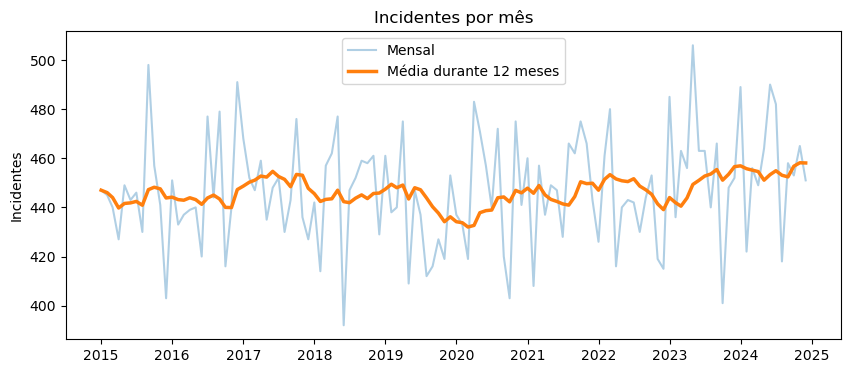

In [33]:
mensal = df.groupby('data', as_index=False)['incidentes'].sum()
mensal['media_12m'] = mensal['incidentes'].rolling(12, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(mensal.data, mensal.incidentes, alpha=.35, label='Mensal')
ax.plot(mensal.data, mensal.media_12m, lw=2.5, label='Média durante 12 meses')
ax.set(title='Incidentes por mês', ylabel='Incidentes'); ax.legend()
plt.savefig('../imagens/serie_mensal.png', dpi=130, bbox_inches='tight'); plt.show()

**observações**

Como evolui durante os anos ? 

pico mensal - início de 2023

pico média durante 12 meses - 2017 a 2018

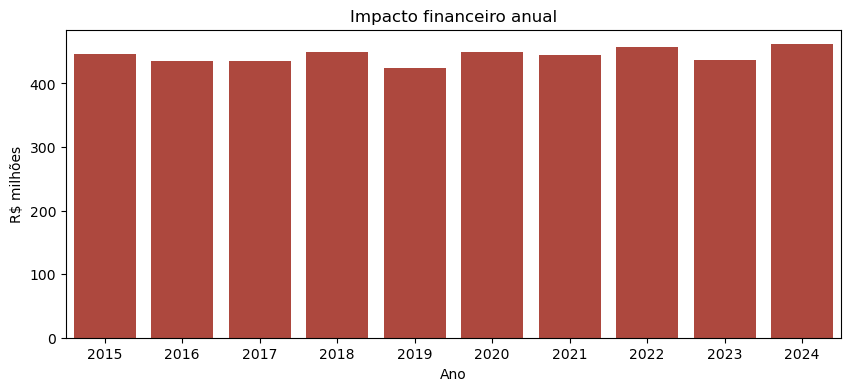

,incidentes,impacto,var_yoy_%
ano,,,
2015,5326,446441713.4,NaN
2016,5367,434883600.7,-2.6
2017,5373,435769100.4,0.2
2018,5350,449183354.5,3.1
2019,5234,424935039.6,-5.4
2020,5351,449166069.9,5.7
2021,5398,444749434.5,-1.0
2022,5269,456681710.9,2.7
2023,5479,436612518.4,-4.4


In [34]:
anual = df.groupby('ano').agg(incidentes=('incidentes','sum'), impacto=('impacto_financeiro','sum'))
anual['var_yoy_%'] = anual.impacto.pct_change()*100
fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(x=anual.index, y=anual.impacto/1e6, ax=ax, color='#c0392b')
ax.set(title='Impacto financeiro anual', xlabel='Ano', ylabel='R$ milhões')
plt.savefig('../imagens/impacto_anual.png', dpi=130, bbox_inches='tight'); plt.show()
anual.round(1)

**Observações**

Barras quase iguais --> impacto anual entre 425 mi e 461 mi 

Variações YoY pequenas --> de -5,4% (2019) a 5,7% (2020 e 2024) oscila mas nada tão grave assim 

2024 é o pior ano --> maior impacto 461 mi e maior nº de incidentes 5.497 

### 8.2 Regiões, UFs e setores

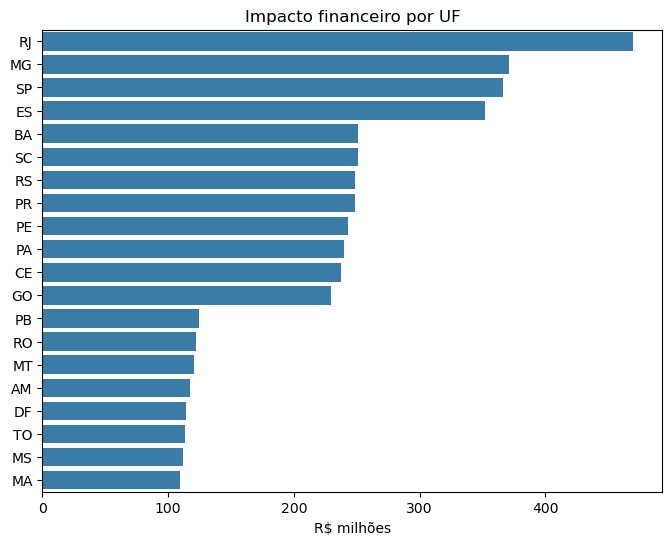

In [35]:
por_uf = df.groupby('uf').impacto_financeiro.sum().sort_values(ascending=False)/1e6
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=por_uf.values, y=por_uf.index, ax=ax, color='#2980b9')
ax.set(title='Impacto financeiro por UF', xlabel='R$ milhões', ylabel='')
plt.savefig('../imagens/impacto_uf.png', dpi=130, bbox_inches='tight'); plt.show()

**Observações**

O impacto financeiro é mais afetado na UF Rio de Janeiro tendo um crescimento consideravelmente maior que as outras UF

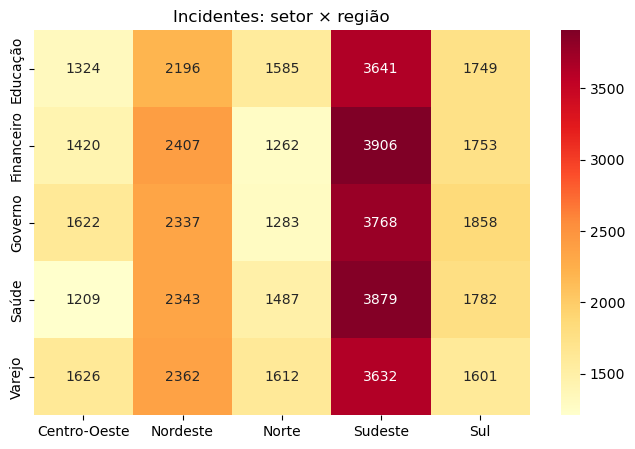

,ufs,registros,impacto_medio
regiao,,,
Centro-Oeste,4,600,958939.0
Nordeste,5,960,1004767.0
Norte,4,600,988246.0
Sudeste,4,1560,999241.0
Sul,3,720,1039128.0


In [36]:
piv = df.pivot_table(index='setor', columns='regiao', values='incidentes', aggfunc='sum')
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set(title='Incidentes: setor × região', xlabel='', ylabel='')
plt.savefig('../imagens/heatmap_setor_regiao.png', dpi=130, bbox_inches='tight'); plt.show()
# Normalização: impacto médio por registro, por região (evita viés de nº de UFs)
df.groupby('regiao').agg(ufs=('uf','nunique'), registros=('uf','size'), impacto_medio=('impacto_financeiro','mean')).round(0)

**observações**

o sudeste é a região mais afetada por incidentes.

Governo e o Financeiro são os setores mais afetados por incidentes 

**Área Crítica** -- Sudeste X Financeiro

### 8.3 Ataques e vulnerabilidades

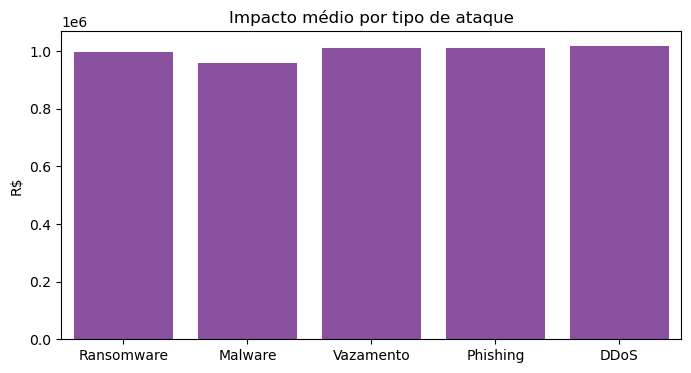

In [37]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=df, x='tipo_ataque', y='impacto_financeiro', errorbar=None, ax=ax, color='#8e44ad')
ax.set(title='Impacto médio por tipo de ataque', xlabel='', ylabel='R$')
plt.savefig('../imagens/ataque_impacto_medio.png', dpi=130, bbox_inches='tight'); plt.show()

**Observações**

Não tem tanta difereça entre o nível das barras pouca oscilação.

DDoS é oq tem mais impacto médio por ataque


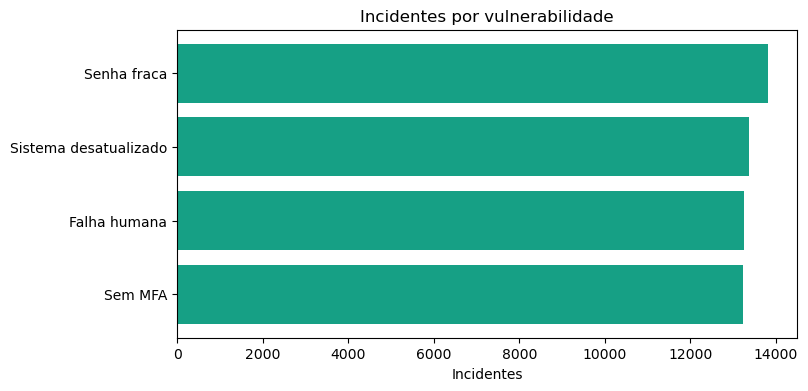

In [38]:
vuln = df.groupby('vulnerabilidade').incidentes.sum().sort_values()
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(vuln.index, vuln.values, color='#16a085'); ax.set(title='Incidentes por vulnerabilidade', xlabel='Incidentes')
plt.savefig('../imagens/vulnerabilidades.png', dpi=130, bbox_inches='tight'); plt.show()

**observações** 

A senha fraca é a maior vulnerabilidade 

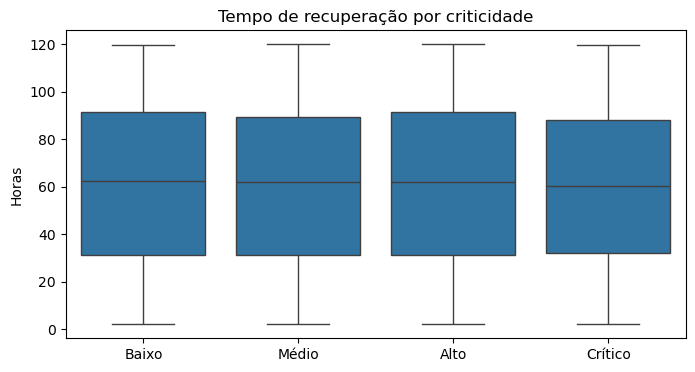

In [39]:
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df, x='nivel_criticidade', y='tempo_recuperacao', order=ordem, ax=ax)
ax.set(title='Tempo de recuperação por criticidade', xlabel='', ylabel='Horas')
plt.savefig('../imagens/tempo_criticidade.png', dpi=130, bbox_inches='tight'); plt.show()

### 8.4 Correlação

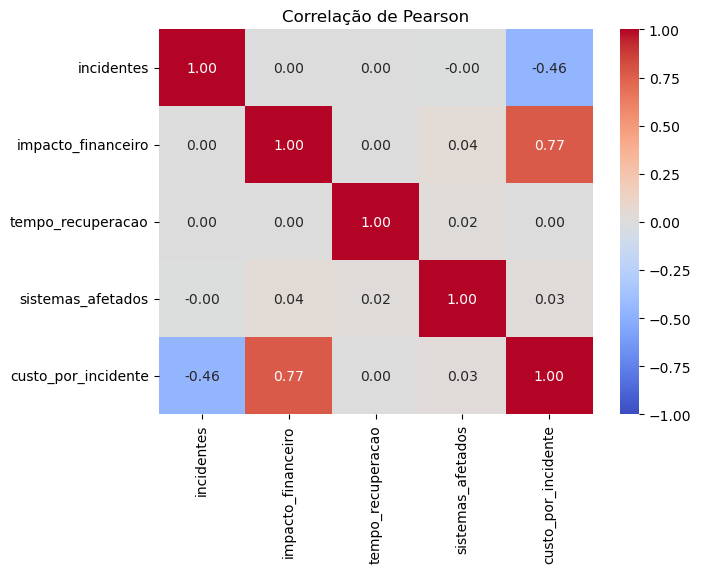

In [40]:
cols = ['incidentes','impacto_financeiro','tempo_recuperacao','sistemas_afetados','custo_por_incidente']
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlação de Pearson')
plt.savefig('../imagens/correlacao.png', dpi=130, bbox_inches='tight'); plt.show()

## 9. Interpretação dos resultados
- **TEMPO:** o volume anual de incidentes e o impacto anual variam pouco e não há tendência forte. 
2024 registra tanto o maior impacto quanto o maior número de incidentes.
- **LOCAL MAIS AFETADO:** o Sudeste concentra mais incidentes e perdas e RJ é a UF de maior impacto. 
Parte disso vem do Uf/registros na região, por isso a tabela normalizada (impacto médio por registro) é importante para não superestimar o efeito regional.
- **SETOR:** Governo, Financeiro, Saúde e Educação têm totais muito próximos; a diferença entre setores é pequena, poém que é o mais frequente é o do Governo e  em seguida o Financeiro.
- **ATAQUES:** Phishing lidera em incidentes e impacto total.
- **VULNERABILIDADES:** Senha fraca é a mais frequente, seguida de sistemas desatualizados, falha humana e ausência de MFA.
- **RESPOSTA STATUS:** a distribuição de status é (aproximadamente 33% Resolvido, Mitigado, Em análise) apenas cerca de um terço dos casos está resolvido.
- **CORRELAÇÃO:** as correlações entre variáveis numéricas são próximas de zero (exceto as derivadas, como custo por incidente), indicando que, nesta base, mais incidentes não implicam maior prejuízo nem maior tempo de recuperação.


## 10. Conclusão
O painel permite identificar onde e como os incidentes se concentram. Os resultados apontam que **senhas fracas, sistemas desatualizados, falha humana e ausência de MFA** são fragilidades igualmente relevantes, e que **apenas ~33% dos casos estão resolvidos**. 

Recomendo: 
1. adotar MFA e política de senhas
2.  automatizar atualizações
3. treinar usuários contra phishing
4. priorizar investimento em RJ/Sudeste e em Governo/Financeiro
5. reduzir o tempo de recuperação com planos de resposta.
